<a href="https://colab.research.google.com/github/sandrazsl/cvar-portfolio-optimization/blob/main/CVaR_Portfolio_Optimization_SandraZhang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tail Risk Portfolio Optimization Across US and HK Equities
## Minimum CVaR vs. Markowitz Mean-Variance

**Sandra Zhang** | 2026

This project compares two approaches to portfolio optimization: the Markowitz mean-variance framework and Conditional Value-at-Risk (CVaR) optimization using the Rockafellar-Uryasev formulation.

Markowitz minimizes portfolio variance, which treats gains and losses as equally risky. CVaR looks at the worst 5% of days and minimizes the average loss there. This project examines whether optimizing for CVaR leads to different portfolio weights than optimizing for variance.

The asset universe consists of 10 US & HK equities: TSLA, TSM, FTNT, O (Realty Income), PFE, CVX, Tencent, Xiaomi, BOC, and CLP Holdings. The data covers July 2023 to July 2026, three years of daily log returns. Data starts after COVID to avoid mixing in the crash and the recovery period, which behaved very differently from current markets.

The Hong Kong dollar is pegged to the US dollar, so the portfolio does not introduce significant currency risk.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import cvxpy as cp
from datetime import datetime

tickers = [
    "TSLA", "TSM", "FTNT", "O", "PFE", "CVX",       # US
    "0700.HK", "1810.HK", "2388.HK", "0002.HK"       # HK
]

labels = [
    "TSLA", "TSM", "FTNT", "O", "PFE", "CVX",
    "Tencent", "Xiaomi", "BOC HK", "CLP"
]

end = datetime(2026, 7, 1)
start = datetime(2023, 7, 1)

df = yf.download(tickers, start=start, end=end, auto_adjust=True)["Close"]
df = df[tickers]
df.columns = labels

prices = df.dropna()

log_returns = np.log(prices / prices.shift(1)).dropna()

# multiply daily mean by 252 trading days, daily std by √252
print(f"Price obs: {len(prices)}  |  Return obs: {len(log_returns)}")
print(f"Date range: {log_returns.index[0].date()} → {log_returns.index[-1].date()}")
print(f"\nAnnualized mean return:\n{(log_returns.mean() * 252).round(4)}")
print(f"\nAnnualized volatility:\n{(log_returns.std() * np.sqrt(252)).round(4)}")

[*********************100%***********************]  10 of 10 completed

Price obs: 714  |  Return obs: 713
Date range: 2023-07-05 → 2026-06-30

Annualized mean return:
TSLA       0.1440
TSM        0.5567
FTNT       0.2550
O          0.0692
PFE       -0.0825
CVX        0.0634
Tencent    0.0951
Xiaomi     0.2398
BOC HK     0.2858
CLP        0.1133
dtype: float64

Annualized volatility:
TSLA       0.5861
TSM        0.3976
FTNT       0.4416
O          0.1899
PFE        0.2507
CVX        0.2362
Tencent    0.3277
Xiaomi     0.4375
BOC HK     0.2241
CLP        0.1528
dtype: float64


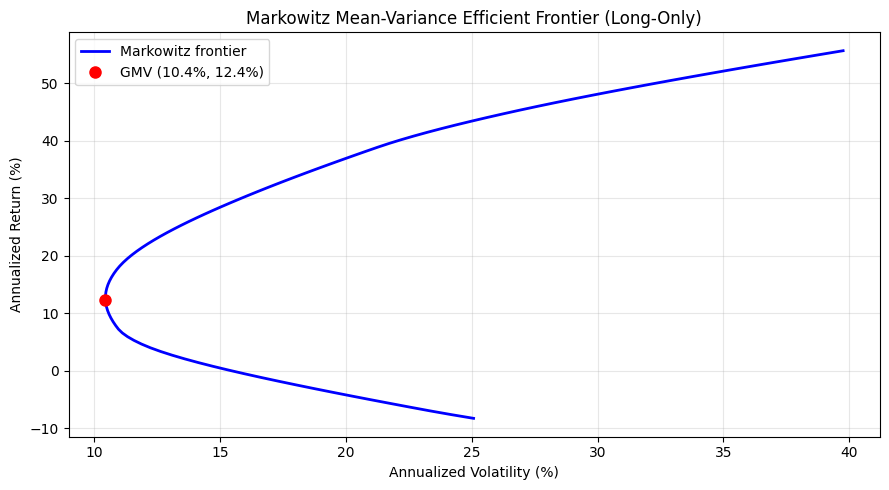

GMV portfolio — return: 12.41%  vol: 10.44%
GMV weights:
TSLA       0.0000
TSM        0.0526
FTNT       0.0421
O          0.2169
PFE        0.0734
CVX        0.1423
Tencent    0.0000
Xiaomi     0.0000
BOC HK     0.0729
CLP        0.3999
dtype: float64


In [3]:
# Markowitz mean-variance efficient frontier

from scipy.optimize import minimize

n = log_returns.shape[1]
mu = log_returns.mean().values * 252
cov = log_returns.cov().values * 252

def portfolio_vol(w):
    return np.sqrt(w @ cov @ w)

def portfolio_ret(w):
    return w @ mu

target_returns = np.linspace(mu.min(), mu.max(), 100)
frontier_vols = []
frontier_weights = []

for i in target_returns:
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1},
        {"type": "eq", "fun": lambda w, i=i: portfolio_ret(w) - i}
    ]
    bnds = [(0, 1)] * n
    w0 = np.ones(n) / n

    res = minimize(portfolio_vol, w0, method="SLSQP", bounds=bnds, constraints=cons,
                   options={"ftol": 1e-12, "maxiter": 1000})
    if res.success:
        frontier_vols.append(portfolio_vol(res.x))
        frontier_weights.append(res.x)
    else:
        frontier_vols.append(np.nan)
        frontier_weights.append(np.full(n, np.nan))

frontier_vols = np.array(frontier_vols)
frontier_weights = np.array(frontier_weights)

# Global minimum variance portfolio
gmv_idx = np.nanargmin(frontier_vols)
gmv_ret = target_returns[gmv_idx]
gmv_vol = frontier_vols[gmv_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(frontier_vols * 100, target_returns * 100, "b-", linewidth=2, label="Markowitz frontier")
ax.plot(gmv_vol * 100, gmv_ret * 100, "ro", markersize=8, label=f"GMV ({gmv_vol*100:.1f}%, {gmv_ret*100:.1f}%)")
ax.set_xlabel("Annualized Volatility (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Markowitz Mean-Variance Efficient Frontier (Long-Only)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"GMV portfolio — return: {gmv_ret*100:.2f}%  vol: {gmv_vol*100:.2f}%")
print(f"GMV weights:\n{pd.Series(frontier_weights[gmv_idx], index=labels).round(4)}")

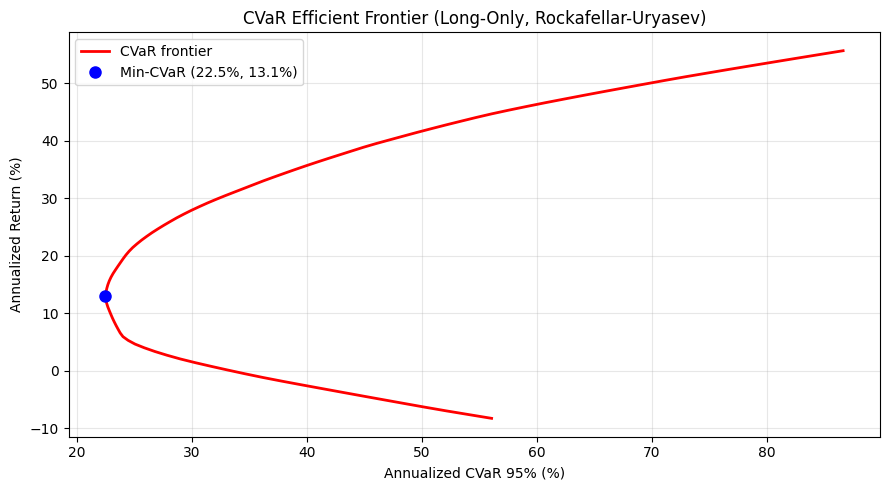

Min-CVaR portfolio — return: 13.06%  CVaR: 22.47%
Min-CVaR weights:
TSLA      -0.0000
TSM        0.0744
FTNT       0.0292
O          0.2083
PFE        0.1132
CVX        0.0948
Tencent    0.0000
Xiaomi     0.0000
BOC HK     0.0941
CLP        0.3860
dtype: float64


In [4]:
# CVaR efficient frontier (Rockafellar-Uryasev)

alpha = 0.05                            # 95% CVaR, alpha is tail probability
N = log_returns.shape[0]                 # number of daily return observations
R = log_returns.values                   # N x n matrix of daily returns, return matrix

# CVaR optimization for each target return
cvar_target_returns = np.linspace(mu.min(), mu.max(), 100)
cvar_frontier = []
cvar_weights = []

for i in cvar_target_returns:
    w = cp.Variable(n)
    zeta = cp.Variable()                 # VaR threshold
    s = cp.Variable(N)                   # auxiliary loss variables

    objective = cp.Minimize(zeta + (1 / alpha) * (1 / N) * cp.sum(s))

    constraints = [
        cp.sum(w) == 1,
        w >= 0,
        w @ mu == i,
        s >= 0,
        s >= -R @ w - zeta
    ]

    prob = cp.Problem(objective, constraints)
    prob.solve(solver=cp.SCS, verbose=False)

    if prob.status == "optimal":
        cvar_frontier.append(prob.value * np.sqrt(252))
        cvar_weights.append(w.value)
    else:
        cvar_frontier.append(np.nan)
        cvar_weights.append(np.full(n, np.nan))

cvar_frontier = np.array(cvar_frontier)
cvar_weights = np.array(cvar_weights)

# Minimum CVaR portfolio
min_cvar_idx = np.nanargmin(cvar_frontier)
min_cvar_ret = cvar_target_returns[min_cvar_idx]
min_cvar_val = cvar_frontier[min_cvar_idx]

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cvar_frontier * 100, cvar_target_returns * 100, "r-", linewidth=2, label="CVaR frontier")
ax.plot(min_cvar_val * 100, min_cvar_ret * 100, "bo", markersize=8,
        label=f"Min-CVaR ({min_cvar_val*100:.1f}%, {min_cvar_ret*100:.1f}%)")
ax.set_xlabel("Annualized CVaR 95% (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("CVaR Efficient Frontier (Long-Only, Rockafellar-Uryasev)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Min-CVaR portfolio — return: {min_cvar_ret*100:.2f}%  CVaR: {min_cvar_val*100:.2f}%")
print(f"Min-CVaR weights:\n{pd.Series(cvar_weights[min_cvar_idx], index=labels).round(4)}")

## Methodology

Markowitz finds the portfolio weights that minimize variance for a given return target. It sweeps across return levels to trace out the efficient frontier. The math is a quadratic program solved with scipy.

However, variance has a problem. It treats a 5% gain the same as a 5% loss. This penalizes the upside, which most investors would rather enjoy.

CVaR takes a different approach. It looks at the worst 5% of days and averages those losses. A portfolio with low CVaR is one where the bad days hurt less. It ignores the upside entirely.

Minimizing CVaR directly is hard because you would first need to find VaR, which is a specific percentile in the loss distribution. VaR jumps discretely from one sorted return to the next (if you slightly change the portfolio weights). It is not smooth, so you can't optimize it directly. Rockafellar and Uryasev (2002) found a way around this. They introduced auxiliary variables that capture how much each day's loss exceeds a threshold. The optimizer finds the best weights and the threshold simultaneously, without computing VaR first. VaR is computed only as a byproduct.

Both methods use daily log returns. Simple returns can't go below -100%, which creates a skewed distribution. Taking the log removes that floor, and the resulting distribution is closer to symmetric, which matters for Markowitz since it assumes normal distribution. CVaR doesn't need that assumption, but using the same return series keeps the comparison fair.

All portfolios are long-only.

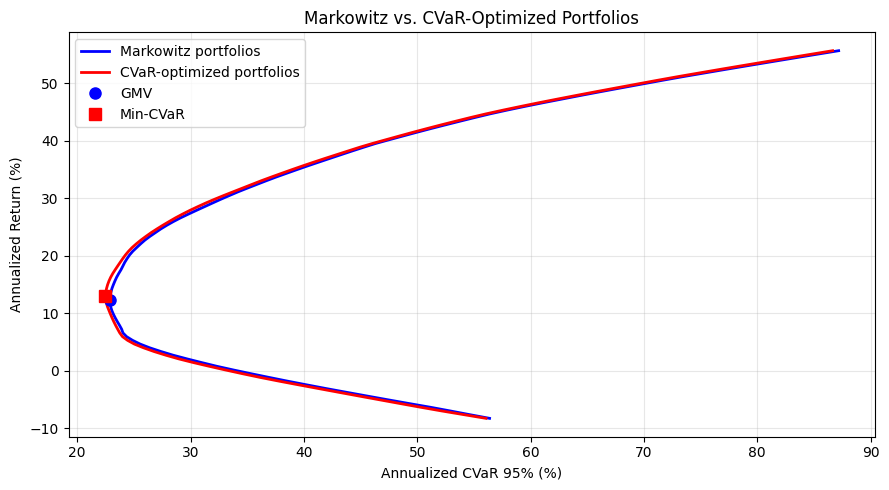

In [5]:
# Overlay both frontiers on CVaR axis

def compute_cvar(w, R, alpha=0.05):
    port_returns = R @ w
    cutoff = int(alpha * len(port_returns))
    sorted_returns = np.sort(port_returns)
    cvar = -sorted_returns[:cutoff].mean() * np.sqrt(252)
    return cvar

markowitz_cvar = []
for i in range(len(frontier_weights)):
    if np.isnan(frontier_weights[i]).any():
        markowitz_cvar.append(np.nan)
    else:
        markowitz_cvar.append(compute_cvar(frontier_weights[i], R))

markowitz_cvar = np.array(markowitz_cvar)

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(markowitz_cvar * 100, target_returns * 100, "b-", linewidth=2, label="Markowitz portfolios")
ax.plot(cvar_frontier * 100, cvar_target_returns * 100, "r-", linewidth=2, label="CVaR-optimized portfolios")
ax.plot(markowitz_cvar[gmv_idx] * 100, gmv_ret * 100, "bo", markersize=8, label="GMV")
ax.plot(min_cvar_val * 100, min_cvar_ret * 100, "rs", markersize=8, label="Min-CVaR")
ax.set_xlabel("Annualized CVaR 95% (%)")
ax.set_ylabel("Annualized Return (%)")
ax.set_title("Markowitz vs. CVaR-Optimized Portfolios")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

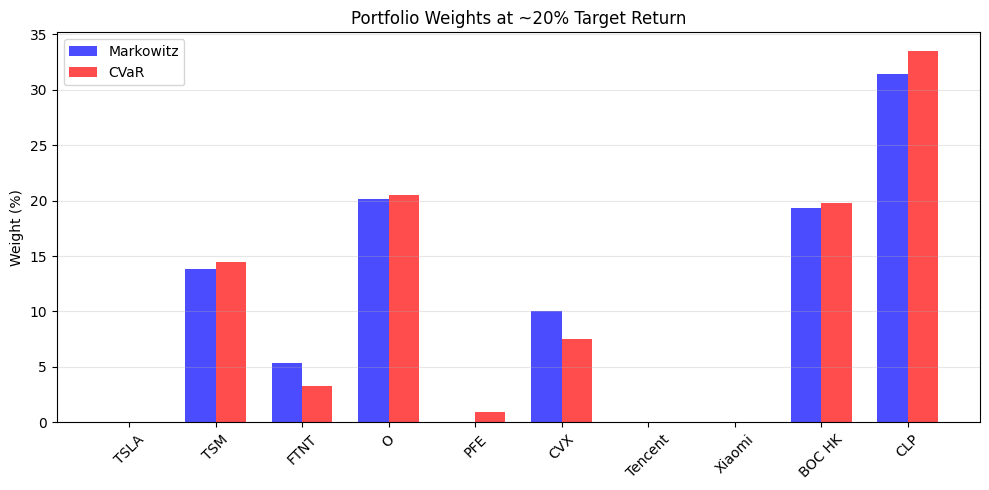

Target return: 20%

         Markowitz   CVaR  Difference
TSLA          0.00   0.00        0.00
TSM          13.84  14.46        0.63
FTNT          5.33   3.24       -2.10
O            20.12  20.51        0.39
PFE           0.00   0.92        0.92
CVX          10.05   7.55       -2.50
Tencent       0.00   0.00        0.00
Xiaomi        0.00   0.00        0.00
BOC HK       19.29  19.82        0.54
CLP          31.38  33.49        2.12


In [6]:
# Weight comparison at 20% target return

target = 0.20

# Find closest Markowitz and CVaR portfolios to target
mk_idx = np.nanargmin(np.abs(target_returns - target))
cv_idx = np.nanargmin(np.abs(cvar_target_returns - target))

mk_w = frontier_weights[mk_idx]
cv_w = cvar_weights[cv_idx]

# Bar chart
x = np.arange(n)
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, mk_w * 100, width, label="Markowitz", color="blue", alpha=0.7)
ax.bar(x + width/2, cv_w * 100, width, label="CVaR", color="red", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Weight (%)")
ax.set_title(f"Portfolio Weights at ~{target*100:.0f}% Target Return")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

comparison = pd.DataFrame({
    "Markowitz": np.round(mk_w * 100, 2),
    "CVaR": np.round(cv_w * 100, 2),
    "Difference": np.round((cv_w - mk_w) * 100, 2)
}, index=labels)
print(f"Target return: {target*100:.0f}%\n")
print(comparison)

In [7]:
# Risk decomposition table

def risk_metrics(w, R, mu, cov, alpha=0.05):
    port_returns = R @ w
    sorted_returns = np.sort(port_returns)
    cutoff = int(alpha * len(port_returns))

    var95 = -sorted_returns[cutoff] * np.sqrt(252)

    # CVaR 95%
    cvar95 = -sorted_returns[:cutoff].mean() * np.sqrt(252)

    # Annualized return and volatility
    ann_ret = w @ mu
    ann_vol = np.sqrt(w @ cov @ w)

    # Sharpe ratio (assuming risk-free rate = 0 for simplicity)
    sharpe = ann_ret / ann_vol

    # Max drawdown
    cum_returns = np.cumprod(1 + port_returns)
    running_max = np.maximum.accumulate(cum_returns)
    drawdowns = (cum_returns - running_max) / running_max
    maxdd = drawdowns.min()

    return {
        "Annualized Return (%)": round(ann_ret * 100, 2),
        "Annualized Volatility (%)": round(ann_vol * 100, 2),
        "VaR 95% (%)": round(var95 * 100, 2),
        "CVaR 95% (%)": round(cvar95 * 100, 2),
        "Sharpe Ratio": round(sharpe, 3),
        "Max Drawdown (%)": round(maxdd * 100, 2)
    }

target = 0.20
mk_idx = np.nanargmin(np.abs(target_returns - target))
cv_idx = np.nanargmin(np.abs(cvar_target_returns - target))

mk_metrics = risk_metrics(frontier_weights[mk_idx], R, mu, cov)
cv_metrics = risk_metrics(cvar_weights[cv_idx], R, mu, cov)

table = pd.DataFrame({"Markowitz": mk_metrics, "CVaR": cv_metrics})
table["Difference"] = table["CVaR"] - table["Markowitz"]

print(f"Risk Decomposition at ~{target*100:.0f}% Target Return\n")
print(table)

Risk Decomposition at ~20% Target Return

                           Markowitz    CVaR  Difference
Annualized Return (%)         20.160  20.160       0.000
Annualized Volatility (%)     11.490  11.580       0.090
VaR 95% (%)                   17.120  17.330       0.210
CVaR 95% (%)                  24.620  24.390      -0.230
Sharpe Ratio                   1.754   1.741      -0.013
Max Drawdown (%)             -14.030 -13.820       0.210


## Results

At the minimum-risk level, both models agree. The Markowitz and the min-CVaR portfolio allocate heavily toward defensive stocks like CLP, Realty Income, and BOC HK. The volatile stocks such as TSLA, Xiaomi, Tencent get zero weight.

The two frontiers nearly overlap when plotted on the same CVaR axis. This could mean that the return distributions over this three-year data are approximately normal. When tails are well-behaved, variance captures most of the risk picture and CVaR has little to add. The two models diverge during periods with fat tails and extreme downside conditions.

At 20% target return, the CVaR-optimized portfolio achieves slightly lower CVaR (24.39% vs 24.62%) and a smaller max drawdown (-13.82% vs -14.03%). The Markowitz portfolio achieves slightly lower volatility and a higher Sharpe ratio. Each model wins on the risk metric it was built to optimize.

One thing worth noting. The CVaR portfolio has a slightly higher VaR (17.33% vs 17.12%) but still achieves lower CVaR, because the optimizer cares about the average severity across all worst days, not the single day at the boundary.

In [11]:
# Allocation tool

def get_allocation(target_ret, model="cvar"):

    if model == "cvar":
        idx = np.nanargmin(np.abs(cvar_target_returns - target_ret))
        weights = cvar_weights[idx]
        risk = cvar_frontier[idx]
        risk_label = "CVaR 95%"
    else:
        idx = np.nanargmin(np.abs(target_returns - target_ret))
        weights = frontier_weights[idx]
        risk = frontier_vols[idx]
        risk_label = "Volatility"

    alloc = pd.Series(weights, index=labels).round(4)
    matched_ret = target_returns[idx]

    print(f"Model: {model.upper()}")
    print(f"Target return: {target_ret*100:.1f}%  |  Matched: {matched_ret*100:.2f}%")
    print(f"{risk_label}: {risk*100:.2f}%\n")
    print("Allocation:\n")
    alloc_df = pd.DataFrame({"Weight (%)": (alloc * 100).round(2)})
    print(alloc_df)
    print(f"\nTotal: {weights.sum()*100:.2f}%")

print("="*40)
cvar_alloc = get_allocation(0.15, model="cvar")
print("\n" + "="*40)
mk_alloc = get_allocation(0.15, model="markowitz")

Model: CVAR
Target return: 15.0%  |  Matched: 14.99%
CVaR 95%: 22.68%

Allocation:

         Weight (%)
TSLA          -0.00
TSM            9.24
FTNT           2.92
O             19.42
PFE            8.59
CVX            9.41
Tencent       -0.00
Xiaomi         0.00
BOC HK        12.53
CLP           37.90

Total: 100.00%

Model: MARKOWITZ
Target return: 15.0%  |  Matched: 14.99%
Volatility: 10.54%

Allocation:

         Weight (%)
TSLA           0.00
TSM            7.86
FTNT           4.57
O             21.93
PFE            3.71
CVX           13.29
Tencent        0.00
Xiaomi         0.00
BOC HK        10.94
CLP           37.70

Total: 100.00%


## Conclusion

The two optimization models produced similar results on this dataset. Over a three-year window with no major market crashes, return distributions stayed close to normal and the efficient frontiers nearly converged. This is an expected outcome, not a flaw. CVaR optimization earns its value during crisis periods when fat tails emerge and variance underestimates downside risk.

The weight differences were small. CVaR allocated more to defensive stocks and less to volatile ones. At 20% target return, CVaR achieved lower tail risk and a smaller max drawdown while giving up a fraction of Sharpe ratio.

The allocation tool in the final cell is for practical use. Pick a target return, and you get the optimal weights. The models rerun quarterly with updated data.